In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings

warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


In [181]:
# Load dataset
df = pd.read_csv(r'D:\ML\ML_20251\archive\Restaurant reviews.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (10000, 8)

Columns: ['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', '7514']

First 5 rows:


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [182]:
# Kiểm tra thông tin dataset
print("Dataset Info:")
print(f"- Total rows: {len(df)}")
print(f"- Missing values:\n{df.isnull().sum()}")
print(f"\n- Rating distribution:\n{df['Rating'].value_counts().sort_index()}")
print(f"\n- Data types:\n{df.dtypes}")

Dataset Info:
- Total rows: 10000
- Missing values:
Restaurant       0
Reviewer        38
Review          45
Rating          38
Metadata        38
Time            38
Pictures         0
7514          9999
dtype: int64

- Rating distribution:
Rating
1       1735
1.5        9
2        684
2.5       19
3       1193
3.5       47
4       2373
4.5       69
5       3832
Like       1
Name: count, dtype: int64

- Data types:
Restaurant     object
Reviewer       object
Review         object
Rating         object
Metadata       object
Time           object
Pictures        int64
7514          float64
dtype: object


In [183]:
import re

def clean_text(text):
    """
    Xử lý văn bản thô
    - Chuyển về chữ thường
    - Loại bỏ ký tự đặc biệt và số
    - Loại bỏ khoảng trắng thừa
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# =========================
# CLEAN RATING
# =========================

print("⚠️ Đang xử lý cột Rating...")

# 1. Chuyển Rating sang numeric, các giá trị không hợp lệ sẽ thành NaN
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# 2. Loại bỏ các dòng có Rating hoặc Review null
print(f"Số dòng trước khi loại NaN: {len(df)}")
df = df.dropna(subset=['Rating', 'Review'])
print(f"Số dòng sau khi loại NaN: {len(df)}")

# 3. Làm tròn rating về số nguyên gần nhất (1–5)
df['Rating'] = df['Rating'].round().astype(int)

# 4. Đảm bảo rating nằm trong [1, 5]
df = df[df['Rating'].between(1, 5)]

print("✓ Đã làm sạch & làm tròn Rating")
print(df['Rating'].value_counts().sort_index())


# =========================
# CLEAN TEXT
# =========================

print("\nĐang xử lý văn bản thô...")
df['text_clean'] = df['Review'].apply(clean_text)


# =========================
# HIỂN THỊ VÍ DỤ
# =========================

print("\nVí dụ văn bản sau khi xử lý:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Original: {df['Review'].iloc[i][:100]}...")
    print(f"Cleaned:  {df['text_clean'].iloc[i][:100]}...")
    print(f"Rating: {df['Rating'].iloc[i]}")


⚠️ Đang xử lý cột Rating...
Số dòng trước khi loại NaN: 10000
Số dòng sau khi loại NaN: 9954
✓ Đã làm sạch & làm tròn Rating
Rating
1    1735
2     712
3    1192
4    2489
5    3826
Name: count, dtype: int64

Đang xử lý văn bản thô...

Ví dụ văn bản sau khi xử lý:

--- Example 1 ---
Original: The ambience was good, food was quite good . had Saturday lunch , which was cost effective .
Good p...
Cleaned:  the ambience was good food was quite good had saturday lunch which was cost effective good place for...
Rating: 5

--- Example 2 ---
Original: Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good e...
Cleaned:  ambience is too good for a pleasant evening service is very prompt food is good over all a good expe...
Rating: 5

--- Example 3 ---
Original: A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal rec...
Cleaned:  a must try great food great ambience thnx for the service by pradeep and subrot

In [184]:
# Khởi tạo TF-IDF Vectorizer
# TfidfVectorizer tự động thực hiện:
# 1. Tokenization (tách từ)
# 2. Loại bỏ stopwords (stop_words='english')
# 3. Tính toán TF-IDF scores
custom_stopwords = list(ENGLISH_STOP_WORDS) + [
    'place', 'order', 'ordered', 'try', 'tried', 'go', 'went', 'came', 'come',
    'got', 'get', 'went', 'time', 'times', 'people',
    'restaurant', 'bit', 'quite', 'really', 'just', 'got', 'visit', 'story', 'book', 'read', 'use', 'staff'
]

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Giới hạn 5000 từ quan trọng nhất
    stop_words='english',     # Loại bỏ stopwords tiếng Anh từ sklearn
    ngram_range=(1, 2),       # Sử dụng unigrams và bigrams
    min_df=2,                 # Từ phải xuất hiện ít nhất 2 lần
    max_df=0.8,               # Từ không xuất hiện quá 80% documents
    lowercase=True,           # Đã lowercase rồi nhưng đảm bảo thêm
    strip_accents='unicode'   # Loại bỏ dấu
)

print("Đang tạo TF-IDF features...")
print("- Tokenization (tách từ)")
print("- Loại bỏ stopwords")
print("- Tính toán TF-IDF scores\n")

# Fit và transform
X_tfidf = tfidf_vectorizer.fit_transform(df['text_clean'])

print(f"✓ TF-IDF matrix shape: {X_tfidf.shape}")
print(f"✓ Số documents: {X_tfidf.shape[0]}")
print(f"✓ Số features (từ sau khi loại stopwords): {X_tfidf.shape[1]}")
print(f"✓ Độ sparse: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")

Đang tạo TF-IDF features...
- Tokenization (tách từ)
- Loại bỏ stopwords
- Tính toán TF-IDF scores

✓ TF-IDF matrix shape: (9954, 5000)
✓ Số documents: 9954
✓ Số features (từ sau khi loại stopwords): 5000
✓ Độ sparse: 99.53%


In [185]:
# Hiển thị một số từ quan trọng nhất (sau khi loại stopwords)
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nVí dụ các từ/cụm từ sau khi tokenize và loại stopwords:")
print(f"First 20 features: {feature_names[:20].tolist()}")
print(f"Last 20 features: {feature_names[-20:].tolist()}")


Ví dụ các từ/cụm từ sau khi tokenize và loại stopwords:
First 20 features: ['able', 'able eat', 'abs', 'absolute', 'absolute sizzlers', 'absolutely', 'absolutely delicious', 'absolutely love', 'absolutely loved', 'abt', 'ac', 'accept', 'acceptable', 'accepted', 'accessible', 'accommodate', 'accommodating', 'accompanied', 'accompanying', 'according']
Last 20 features: ['youll', 'young', 'youre', 'youre looking', 'youve', 'yum', 'yum tree', 'yum yum', 'yumm', 'yummm', 'yummy', 'yummy food', 'zafrani', 'zega', 'zero', 'zinger', 'zings', 'zomato', 'zomato delivery', 'zomato gold']


# 🎯 3.3. Chuẩn Bị Dữ Liệu Cho Model


In [186]:
# Tạo features matrix (dùng TF-IDF features trực tiếp)
X = X_tfidf  # Sparse matrix, giữ nguyên

# Target variable là rating (để dự đoán)
y = df['Rating'].values

print(f"Features shape (X): {X.shape}")
print(f"Features type: {type(X)}")
print(f"Target shape (y): {y.shape}")
print(f"\nTarget distribution (rating):")
print(pd.Series(y).value_counts().sort_index())

Features shape (X): (9954, 5000)
Features type: <class 'scipy.sparse._csr.csr_matrix'>
Target shape (y): (9954,)

Target distribution (rating):
1    1735
2     712
3    1192
4    2489
5    3826
Name: count, dtype: int64


## 3.4. Train/Test Split


In [187]:
# Chia train/test (lưu indices để mapping về dataframe sau)
X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
    X, y, range(len(y)),
    test_size=0.2, 
    random_state=42
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain rating distribution:")
print(pd.Series(y_train).value_counts().sort_index())
print(f"\nTest rating distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train set: (7963, 5000)
Test set: (1991, 5000)

Train rating distribution:
1    1388
2     558
3     959
4    1977
5    3081
Name: count, dtype: int64

Test rating distribution:
1    347
2    154
3    233
4    512
5    745
Name: count, dtype: int64


In [188]:
print("🌲 Training Random Forest Classifier...\n")

# Khởi tạo Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,              # Giảm từ 20 xuống 15 để giảm độ phức tạp
    min_samples_split=10,      # Tăng từ 5 lên 10 để yêu cầu nhiều samples hơn trước khi split
    min_samples_leaf=5,        # Tăng từ 2 lên 5 để yêu cầu nhiều samples hơn trong leaf nodes
    max_features='sqrt',        # Giới hạn số features tại mỗi split (sqrt thay vì tất cả)
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',  # Handle class imbalance
    verbose=1
)

# Train model
rf_model.fit(X_train, y_train)

print("\n✓ Random Forest training completed!")

🌲 Training Random Forest Classifier...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s



✓ Random Forest training completed!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [189]:
# Phân tích Feature Importance (Information Gain)
print("📈 Feature Importance Analysis (Information Gain)\n" + "="*60)

# Lấy feature importance
feature_importance = rf_model.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()

# Tạo DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Top 20 từ quan trọng nhất
top_features = importance_df.head(20)

print("\nTop 20 từ quan trọng nhất (theo Information Gain):\n")
for idx, row in top_features.iterrows():
    print(f"  {row['Feature']:20s} → Gain: {row['Importance']:.6f}")

print("\n" + "="*60)
print(f"\n💡 VÍ DỤ: Nếu từ 'excellent' có Gain cao:")
print(f"   - Khi có từ 'excellent': đánh giá thường → 4-5 sao")
print(f"   - Khi không có: đánh giá phân tán hơn")
print(f"   - Giảm entropy → Gain dương → Từ tốt để phân loại")

📈 Feature Importance Analysis (Information Gain)

Top 20 từ quan trọng nhất (theo Information Gain):

  good                 → Gain: 0.034765
  bad                  → Gain: 0.031093
  worst                → Gain: 0.026643
  awesome              → Gain: 0.023854
  excellent            → Gain: 0.021708
  best                 → Gain: 0.021604
  ambience             → Gain: 0.018183
  order                → Gain: 0.017923
  great                → Gain: 0.016627
  loved                → Gain: 0.015912
  nice                 → Gain: 0.015026
  place                → Gain: 0.014732
  ordered              → Gain: 0.014573
  dont                 → Gain: 0.014565
  average              → Gain: 0.014278
  try                  → Gain: 0.014179
  amazing              → Gain: 0.013853
  waste                → Gain: 0.013284
  ok                   → Gain: 0.011311
  worst experience     → Gain: 0.010894


💡 VÍ DỤ: Nếu từ 'excellent' có Gain cao:
   - Khi có từ 'excellent': đánh giá thường → 4-5 sao
 

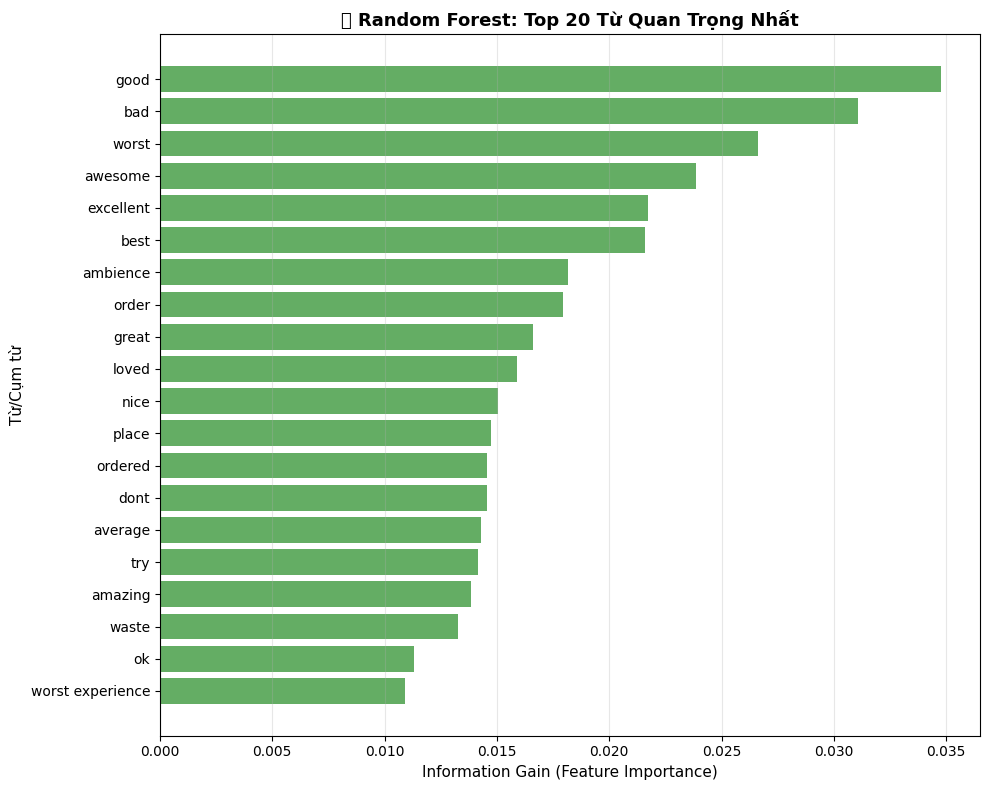


✓ Các từ phía trên có Gain cao nhất → Quan trọng nhất để phân loại rating


In [190]:
# Visualize Top 20 Feature Importance
plt.figure(figsize=(10, 8))

top_20 = importance_df.head(20)
plt.barh(range(len(top_20)), top_20['Importance'], color='forestgreen', alpha=0.7)
plt.yticks(range(len(top_20)), top_20['Feature'])
plt.xlabel('Information Gain (Feature Importance)', fontsize=11)
plt.ylabel('Từ/Cụm từ', fontsize=11)
plt.title('🌲 Random Forest: Top 20 Từ Quan Trọng Nhất', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Các từ phía trên có Gain cao nhất → Quan trọng nhất để phân loại rating")

In [191]:
# Đánh giá trên Test set
print("📊 Random Forest Evaluation - Test Set\n" + "="*50)

y_pred_test = rf_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test, average='weighted')

print(f"\n✓ Test Accuracy: {accuracy_test*100:.2f}%")
print(f"✓ Test F1 Score (weighted): {f1_test:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_test))

📊 Random Forest Evaluation - Test Set

✓ Test Accuracy: 57.01%
✓ Test F1 Score (weighted): 0.5603

Classification Report:
              precision    recall  f1-score   support

           1       0.57      0.81      0.67       347
           2       0.24      0.19      0.21       154
           3       0.38      0.28      0.32       233
           4       0.50      0.48      0.49       512
           5       0.72      0.69      0.70       745

    accuracy                           0.57      1991
   macro avg       0.48      0.49      0.48      1991
weighted avg       0.56      0.57      0.56      1991



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


📊 So Sánh Độ Chính Xác: Train vs Test - Random Forest

✓ Train Accuracy: 68.19%
✓ Test Accuracy:  57.01%

✓ Train F1 Score: 0.6791
✓ Test F1 Score:  0.5603

📈 Overfitting Gap: 11.18%
   ⚠️ Model có dấu hiệu overfitting nhẹ


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


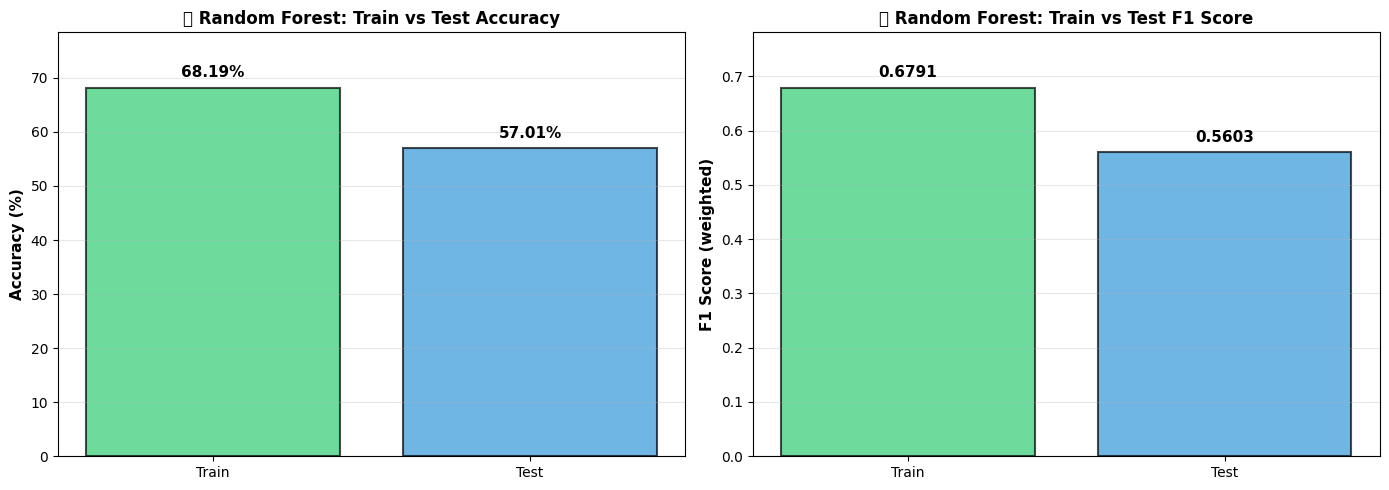

In [192]:
# So sánh độ chính xác trên tập Train và Test
print("📊 So Sánh Độ Chính Xác: Train vs Test - Random Forest\n" + "="*60)

# Predictions trên tập train
y_pred_train = rf_model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train, average='weighted')

print(f"\n✓ Train Accuracy: {accuracy_train*100:.2f}%")
print(f"✓ Test Accuracy:  {accuracy_test*100:.2f}%")
print(f"\n✓ Train F1 Score: {f1_train:.4f}")
print(f"✓ Test F1 Score:  {f1_test:.4f}")

# Tính overfitting gap
overfitting_gap = accuracy_train - accuracy_test
print(f"\n📈 Overfitting Gap: {overfitting_gap*100:.2f}%")
if overfitting_gap < 0.05:
    print("   ✅ Model không bị overfitting nghiêm trọng")
elif overfitting_gap < 0.15:
    print("   ⚠️ Model có dấu hiệu overfitting nhẹ")
else:
    print("   🚨 Model bị overfitting nghiêm trọng!")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart so sánh Accuracy
categories = ['Train', 'Test']
accuracies = [accuracy_train*100, accuracy_test*100]
colors = ['#2ecc71', '#3498db']

bars1 = axes[0].bar(categories, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0].set_title('🌲 Random Forest: Train vs Test Accuracy', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, max(accuracies) * 1.15])
axes[0].grid(axis='y', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars1, accuracies)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(accuracies)*0.02,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Bar chart so sánh F1 Score
f1_scores = [f1_train, f1_test]
bars2 = axes[1].bar(categories, f1_scores, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('F1 Score (weighted)', fontsize=11, fontweight='bold')
axes[1].set_title('🌲 Random Forest: Train vs Test F1 Score', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, max(f1_scores) * 1.15])
axes[1].grid(axis='y', alpha=0.3)

for i, (bar, f1) in enumerate(zip(bars2, f1_scores)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(f1_scores)*0.02,
                f'{f1:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)

## 4.2. Logistic Regression (Softmax)


In [193]:

from sklearn.linear_model import LogisticRegression

# ĐIỀU CHỈNH: Tìm balance tốt hơn giữa overfitting và accuracy
# C=0.3: Regularization vừa phải (không quá mạnh như 0.1, không quá yếu như 1.0)
softmax_model = LogisticRegression(
    multi_class='multinomial', 
    solver='saga',         
    max_iter=3000,         # Tăng iterations để model học tốt hơn
    random_state=42,
    C=0.3,                 # Regularization VỪA PHẢI (balance giữa 0.1 và 1.0)
    penalty='l2',          
    class_weight='balanced',
    tol=0.001,             # Giảm tolerance để train kỹ hơn
    warm_start=False
)

print("⏳ Đang huấn luyện Softmax Regression với BALANCED Regularization...")
print("   📌 Regularization: L2 with C=0.3 (VỪA PHẢI - balance overfitting vs accuracy)")
print("   📌 Solver: SAGA")
print("   📌 Class weight: Balanced")
print("   📌 Max iterations: 3000 (train kỹ hơn)")
softmax_model.fit(X_train, y_train)
print("✅ Huấn luyện xong!")

import pandas as pd
import numpy as np

# Dự đoán trên tập test
y_pred_softmax = softmax_model.predict(X_test)
y_prob_softmax = softmax_model.predict_proba(X_test)

# Tạo bảng kết quả chi tiết để phân tích
analysis_df = pd.DataFrame({
    'Review_Index': test_idx,
    'Thực_tế (Star)': y_test,
    'Máy_dự_đoán (Star)': y_pred_softmax,
})

# Convert rating columns to numeric type
analysis_df['Thực_tế (Star)'] = pd.to_numeric(analysis_df['Thực_tế (Star)'], errors='coerce')
analysis_df['Máy_dự_đoán (Star)'] = pd.to_numeric(analysis_df['Máy_dự_đoán (Star)'], errors='coerce')

# Tính độ lệch (Gap) giữa thực tế và dự đoán
analysis_df['Độ_lệch'] = abs(analysis_df['Thực_tế (Star)'] - analysis_df['Máy_dự_đoán (Star)'])

# --- LOGIC QUYẾT ĐỊNH ---
analysis_df['Trạng_thái'] = np.where(analysis_df['Độ_lệch'] > 1, '⚠️ Bất thường (Fake/Spam)', '✅ Nhất quán')

# Độ tin cậy
analysis_df['Độ_tin_cậy_Model'] = np.max(y_prob_softmax, axis=1)

# Lọc ra các trường hợp Bất thường
suspicious_cases = analysis_df[analysis_df['Trạng_thái'] == '⚠️ Bất thường (Fake/Spam)'].sort_values(by='Độ_lệch', ascending=False)

print(f"\nTổng số reviews kiểm tra: {len(analysis_df)}")
print(f"Số lượng review Nhất quán: {len(analysis_df[analysis_df['Trạng_thái'] == '✅ Nhất quán'])}")
print(f"Số lượng review Bất thường (Nghi ngờ): {len(suspicious_cases)}")
print(f"Tỷ lệ phát hiện nghi vấn: {len(suspicious_cases)/len(analysis_df)*100:.2f}%")

print("\n=== TOP 5 TRƯỜNG HỢP MÂU THUẪN NHẤT (CẦN KIỂM TRA) ===")
print(suspicious_cases[['Review_Index', 'Thực_tế (Star)', 'Máy_dự_đoán (Star)', 'Độ_lệch', 'Độ_tin_cậy_Model']].head(5))

# So sánh nhanh với performance trước đó
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_train, softmax_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred_softmax)
gap = train_acc - test_acc

print(f"\n📊 PERFORMANCE SUMMARY:")
print(f"   Train Accuracy: {train_acc*100:.2f}%")
print(f"   Test Accuracy:  {test_acc*100:.2f}%")
print(f"   Overfitting Gap: {gap*100:.2f}%")
if gap < 0.10:
    print("   ✅ Overfitting được kiểm soát tốt!")
elif gap < 0.15:
    print("   ⚠️ Overfitting ở mức chấp nhận được")
else:
    print("   🚨 Vẫn còn overfitting cao")


⏳ Đang huấn luyện Softmax Regression với BALANCED Regularization...
   📌 Regularization: L2 with C=0.3 (VỪA PHẢI - balance overfitting vs accuracy)
   📌 Solver: SAGA
   📌 Class weight: Balanced
   📌 Max iterations: 3000 (train kỹ hơn)
✅ Huấn luyện xong!

Tổng số reviews kiểm tra: 1991
Số lượng review Nhất quán: 1798
Số lượng review Bất thường (Nghi ngờ): 193
Tỷ lệ phát hiện nghi vấn: 9.69%

=== TOP 5 TRƯỜNG HỢP MÂU THUẪN NHẤT (CẦN KIỂM TRA) ===
      Review_Index  Thực_tế (Star)  Máy_dự_đoán (Star)  Độ_lệch  \
1984          9681               5                   1        4   
219            367               1                   5        4   
402           6365               5                   1        4   
411           1501               5                   1        4   
480           5728               1                   5        4   

      Độ_tin_cậy_Model  
1984          0.245537  
219           0.556867  
402           0.242080  
411           0.262086  
480           0.333182 

⏳ Đang dự đoán trên tập test...

📊 ĐỘ CHÍNH XÁC TỔNG THỂ: 59.12%
------------------------------------------------------------
Báo cáo chi tiết từng lớp sao:
              precision    recall  f1-score   support

           1       0.69      0.71      0.70       347
           2       0.21      0.30      0.25       154
           3       0.35      0.35      0.35       233
           4       0.52      0.51      0.51       512
           5       0.79      0.73      0.76       745

    accuracy                           0.59      1991
   macro avg       0.51      0.52      0.51      1991
weighted avg       0.61      0.59      0.60      1991


🔎 KẾT QUẢ PHÁT HIỆN GIAN LẬN / KHÔNG NHẤT QUÁN
Tổng số mẫu kiểm tra: 1991 reviews
Số mẫu NHẤT QUÁN:     1798
Số mẫu BẤT THƯỜNG:    193 (Chiếm 9.69%)
------------------------------------------------------------

🚨 TOP 5 TRƯỜNG HỢP BẤT THƯỜNG NHẤT (CẦN KIỂM TRA):

[Case #530]
📝 Nội dung: "I have ordered chicken shawarma with salad and pizza square and I

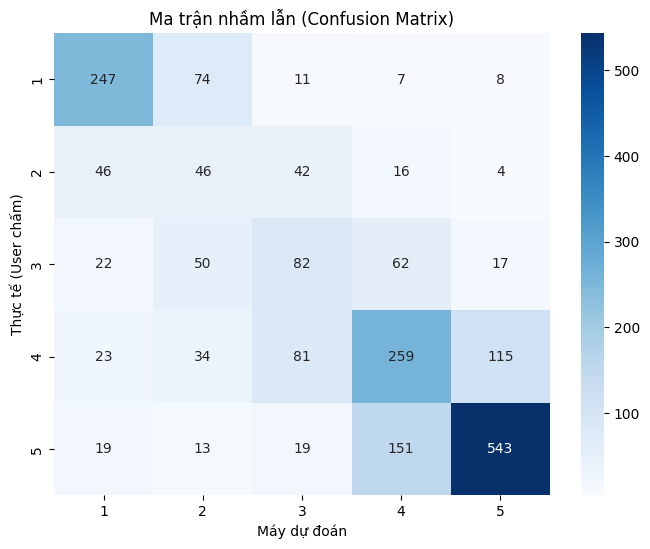

In [194]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Dự đoán trên toàn bộ tập test
print("⏳ Đang dự đoán trên tập test...")
y_test_pred = softmax_model.predict(X_test)
y_test_prob = softmax_model.predict_proba(X_test) # Lấy xác suất để tính độ tin cậy

# 2. Tạo bảng kết quả chi tiết (Kết hợp Text gốc để dễ soi lỗi)
# Sử dụng reset_index để lấy đúng các dòng tương ứng
test_reviews = df.reset_index(drop=True).loc[test_idx, 'Review'].values

test_results = pd.DataFrame({
    'Review_Gốc': test_reviews,  # Lấy lại nội dung review từ cột Review
    'Thực_tế (Star)': pd.to_numeric(y_test, errors='coerce'),
    'Máy_dự_đoán': pd.to_numeric(y_test_pred, errors='coerce'),
    'Độ_tin_cậy_Máy (%)': np.max(y_test_prob, axis=1) * 100
})

# 3. Tính toán độ lệch (Logic Nhất quán)
test_results['Độ_lệch'] = abs(test_results['Thực_tế (Star)'] - test_results['Máy_dự_đoán'])
test_results['Trạng_thái'] = np.where(test_results['Độ_lệch'] > 1, '🚨 FAKE / BẤT THƯỜNG', '✅ Hợp lệ')

# =============================================================================
# HIỂN THỊ BÁO CÁO
# =============================================================================

# --- Phần 1: Đánh giá kỹ thuật (Accuracy) ---
acc = accuracy_score(y_test, y_test_pred)
print(f"\n📊 ĐỘ CHÍNH XÁC TỔNG THỂ: {acc*100:.2f}%")
print("-" * 60)
print("Báo cáo chi tiết từng lớp sao:")
print(classification_report(y_test, y_test_pred))

# --- Phần 2: Đánh giá tính nhất quán (Logic bài toán) ---
inconsistent_cases = test_results[test_results['Trạng_thái'] == '🚨 FAKE / BẤT THƯỜNG']
fake_ratio = len(inconsistent_cases) / len(test_results) * 100

print("\n" + "="*60)
print("🔎 KẾT QUẢ PHÁT HIỆN GIAN LẬN / KHÔNG NHẤT QUÁN")
print("="*60)
print(f"Tổng số mẫu kiểm tra: {len(test_results)} reviews")
print(f"Số mẫu NHẤT QUÁN:     {len(test_results) - len(inconsistent_cases)}")
print(f"Số mẫu BẤT THƯỜNG:    {len(inconsistent_cases)} (Chiếm {fake_ratio:.2f}%)")
print("-" * 60)

print("\n🚨 TOP 5 TRƯỜNG HỢP BẤT THƯỜNG NHẤT (CẦN KIỂM TRA):")
top_fakes = inconsistent_cases.sort_values(by=['Độ_lệch', 'Độ_tin_cậy_Máy (%)'], ascending=[False, False]).head(5)

for idx, row in top_fakes.iterrows():
    print(f"\n[Case #{idx}]")
    print(f"📝 Nội dung: \"{row['Review_Gốc'][:150]}...\"")
    print(f"⭐ Khách chấm: {row['Thực_tế (Star)']} | 🤖 Máy đoán: {row['Máy_dự_đoán']} (Tin cậy {row['Độ_tin_cậy_Máy (%)']:.1f}%)")
    print(f"⚠️ Độ lệch: {row['Độ_lệch']} sao")

# --- Phần 4: Vẽ Confusion Matrix (Ma trận nhầm lẫn) ---
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=softmax_model.classes_,
            yticklabels=softmax_model.classes_)
plt.xlabel('Máy dự đoán')
plt.ylabel('Thực tế (User chấm)')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.show()


⏳ Đang tính toán trên tập Train và Test...


,Metric,Train Set,Test Set
0,Accuracy (Độ chính xác),72.55%,59.12%
1,Precision (Macro),68.77%,51.33%
2,Recall (Macro),73.16%,51.94%
3,F1-Score (Macro),70.41%,51.46%


⚠️ CẢNH BÁO: Có dấu hiệu Overfitting (Train hơn Test 13.4%)


,Tập dữ liệu,Tổng số mẫu,Số mẫu Bất thường (Gap > 1),Tỷ lệ (%)
0,Train (Huấn luyện),7963,658,8.26%
1,Test (Kiểm thử),1991,193,9.69%


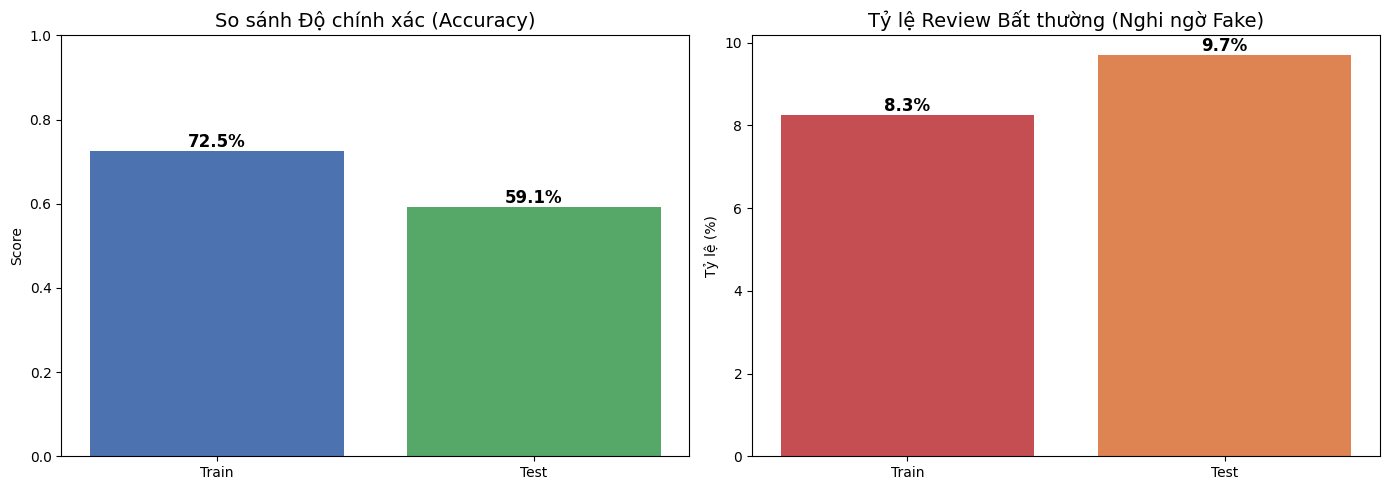

In [195]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Dự đoán trên cả 2 tập
print("⏳ Đang tính toán trên tập Train và Test...")
y_train_pred = softmax_model.predict(X_train)
y_test_pred = softmax_model.predict(X_test)

# 2. Tính các chỉ số kỹ thuật (Metrics)
metrics_data = {
    'Metric': ['Accuracy (Độ chính xác)', 'Precision (Macro)', 'Recall (Macro)', 'F1-Score (Macro)'],
    'Train Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, average='macro', zero_division=0),
        recall_score(y_train, y_train_pred, average='macro', zero_division=0),
        f1_score(y_train, y_train_pred, average='macro', zero_division=0)
    ],
    'Test Set': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, average='macro', zero_division=0),
        recall_score(y_test, y_test_pred, average='macro', zero_division=0),
        f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    ]
}
df_metrics = pd.DataFrame(metrics_data)

# 3. Tính tỷ lệ phát hiện "Bất thường/Fake" (Gap > 1)
def calculate_inconsistency(y_true, y_pred):
    # Convert arrays to numeric types before calculation
    y_true_numeric = pd.to_numeric(y_true, errors='coerce')
    y_pred_numeric = pd.to_numeric(y_pred, errors='coerce')

    gap = np.abs(y_true_numeric - y_pred_numeric)
    inconsistent_count = np.sum(gap > 1) # Đếm số lượng lệch > 1 sao
    return inconsistent_count, inconsistent_count / len(y_true) * 100

train_fake_count, train_fake_ratio = calculate_inconsistency(y_train, y_train_pred)
test_fake_count, test_fake_ratio = calculate_inconsistency(y_test, y_test_pred)

display(df_metrics.style.format("{:.2%}", subset=['Train Set', 'Test Set']))

# Đánh giá nhanh Overfitting
acc_gap = metrics_data['Train Set'][0] - metrics_data['Test Set'][0]
if acc_gap > 0.10: # Lệch > 10%
    print(f"⚠️ CẢNH BÁO: Có dấu hiệu Overfitting (Train hơn Test {acc_gap*100:.1f}%)")
elif acc_gap < -0.05:
    print(f"⚠️ LẠ: Test đang cao hơn Train (Có thể do phân bố dữ liệu chưa đều)")
else:
    print(f"✅ TỐT: Mô hình ổn định (Train và Test chênh lệch nhỏ: {acc_gap*100:.1f}%)")



compare_fake = pd.DataFrame({
    'Tập dữ liệu': ['Train (Huấn luyện)', 'Test (Kiểm thử)'],
    'Tổng số mẫu': [len(y_train), len(y_test)],
    'Số mẫu Bất thường (Gap > 1)': [train_fake_count, test_fake_count],
    'Tỷ lệ (%)': [f"{train_fake_ratio:.2f}%", f"{test_fake_ratio:.2f}%"]
})
display(compare_fake)


plt.figure(figsize=(14, 5))

# Biểu đồ 1: Accuracy Train vs Test
plt.subplot(1, 2, 1)
x_labels = ['Train', 'Test']
y_values = [metrics_data['Train Set'][0], metrics_data['Test Set'][0]]
bars = plt.bar(x_labels, y_values, color=['#4c72b0', '#55a868'])
plt.ylim(0, 1.0)
plt.title('So sánh Độ chính xác (Accuracy)', fontsize=14)
plt.ylabel('Score')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Biểu đồ 2: Tỷ lệ phát hiện Bất thường
plt.subplot(1, 2, 2)
y_fake_vals = [train_fake_ratio, test_fake_ratio]
bars2 = plt.bar(x_labels, y_fake_vals, color=['#c44e52', '#dd8452'])
plt.title('Tỷ lệ Review Bất thường (Nghi ngờ Fake)', fontsize=14)
plt.ylabel('Tỷ lệ (%)')
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4.5. Naive Bayes


In [196]:
print("🎯 Training Naive Bayes (Multinomial)...\n")

# Khởi tạo Naive Bayes
nb_model = MultinomialNB(
    alpha=0.5   # smoothing, có thể thử 0.1–1.0
)

# Train model
nb_model.fit(X_train, y_train)

print("\n✓ Naive Bayes training completed!")


🎯 Training Naive Bayes (Multinomial)...


✓ Naive Bayes training completed!


📊 So Sánh Độ Chính Xác: Train vs Test - Naive Bayes

✓ Train Accuracy: 72.61%
✓ Test Accuracy:  61.18%

✓ Train F1 Score: 0.6967
✓ Test F1 Score:  0.5676

📈 Overfitting Gap: 11.44%
   ⚠️ Model có dấu hiệu overfitting nhẹ


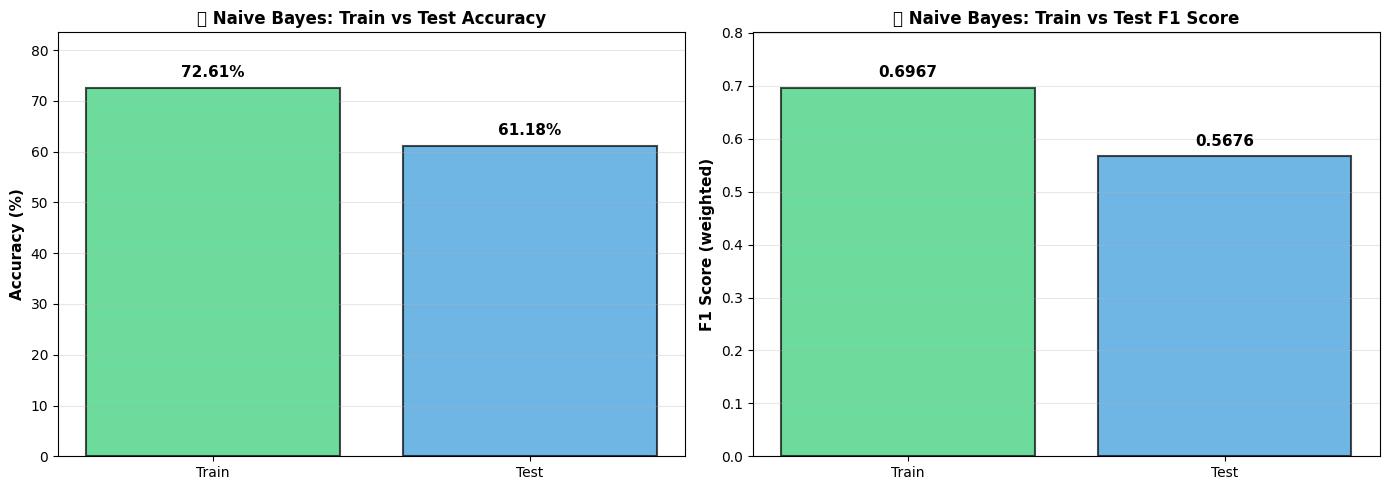

In [ ]:
# ===============================
# So sánh Train vs Test - Naive Bayes
# ===============================

print("📊 So Sánh Độ Chính Xác: Train vs Test - Naive Bayes\n" + "="*60)

# Predictions
y_pred_train_nb = nb_model.predict(X_train)
y_pred_test_nb  = nb_model.predict(X_test)

# Metrics
accuracy_train_nb = accuracy_score(y_train, y_pred_train_nb)
accuracy_test_nb  = accuracy_score(y_test, y_pred_test_nb)

f1_train_nb = f1_score(y_train, y_pred_train_nb, average='weighted')
f1_test_nb  = f1_score(y_test, y_pred_test_nb, average='weighted')

print(f"\n✓ Train Accuracy: {accuracy_train_nb*100:.2f}%")
print(f"✓ Test Accuracy:  {accuracy_test_nb*100:.2f}%")
print(f"\n✓ Train F1 Score: {f1_train_nb:.4f}")
print(f"✓ Test F1 Score:  {f1_test_nb:.4f}")

# Overfitting gap
overfitting_gap = accuracy_train_nb - accuracy_test_nb
print(f"\n📈 Overfitting Gap: {overfitting_gap*100:.2f}%")

if overfitting_gap < 0.05:
    print("   ✅ Model không bị overfitting nghiêm trọng")
elif overfitting_gap < 0.15:
    print("   ⚠️ Model có dấu hiệu overfitting nhẹ")
else:
    print("   🚨 Model bị overfitting nghiêm trọng!")

# ===============================
# Visualization
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

categories = ['Train', 'Test']
colors = ['#2ecc71', '#3498db']

# Accuracy bar chart
accuracies = [accuracy_train_nb*100, accuracy_test_nb*100]
bars1 = axes[0].bar(categories, accuracies, color=colors, alpha=0.7,
                    edgecolor='black', linewidth=1.5)

axes[0].set_ylabel('Accuracy (%)', fontsize=11, fontweight='bold')
axes[0].set_title('📘 Naive Bayes: Train vs Test Accuracy',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim([0, max(accuracies) * 1.15])
axes[0].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(accuracies)*0.02,
                 f'{acc:.2f}%',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

# F1 bar chart
f1_scores = [f1_train_nb, f1_test_nb]
bars2 = axes[1].bar(categories, f1_scores, color=colors, alpha=0.7,
                    edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('F1 Score (weighted)', fontsize=11, fontweight='bold')
axes[1].set_title('📘 Naive Bayes: Train vs Test F1 Score',
                  fontsize=12, fontweight='bold')
axes[1].set_ylim([0, max(f1_scores) * 1.15])
axes[1].grid(axis='y', alpha=0.3)

for bar, f1 in zip(bars2, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(f1_scores)*0.02,
                 f'{f1:.4f}',
                 ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

plt.tight_layout()

plt.show()

print("\n" + "="*60)


📊 SO SÁNH HIỆU NĂNG 3 MÔ HÌNH - HOLD-OUT VALIDATION (80/20 SPLIT)

🔄 Đang đánh giá các mô hình...

Đang đánh giá: Random Forest...
Đang đánh giá: Softmax Regression...
Đang đánh giá: Naive Bayes...

📋 BẢNG SO SÁNH CHI TIẾT
             Model Train Accuracy Test Accuracy Overfitting Gap Train F1 (Macro) Test F1 (Macro) Train Precision (Macro) Test Precision (Macro) Train Recall (Macro) Test Recall (Macro) Training Time (s)
     Random Forest         68.19%        57.01%          11.18%           0.6420          0.4798                  0.6476                 0.4825               0.6486              0.4894            0.0970
Softmax Regression         72.55%        59.12%          13.43%           0.7041          0.5146                  0.6877                 0.5133               0.7316              0.5194            0.0020
       Naive Bayes         72.61%        61.18%          11.44%           0.5946          0.4492                  0.7919                 0.5274               0.5894    

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


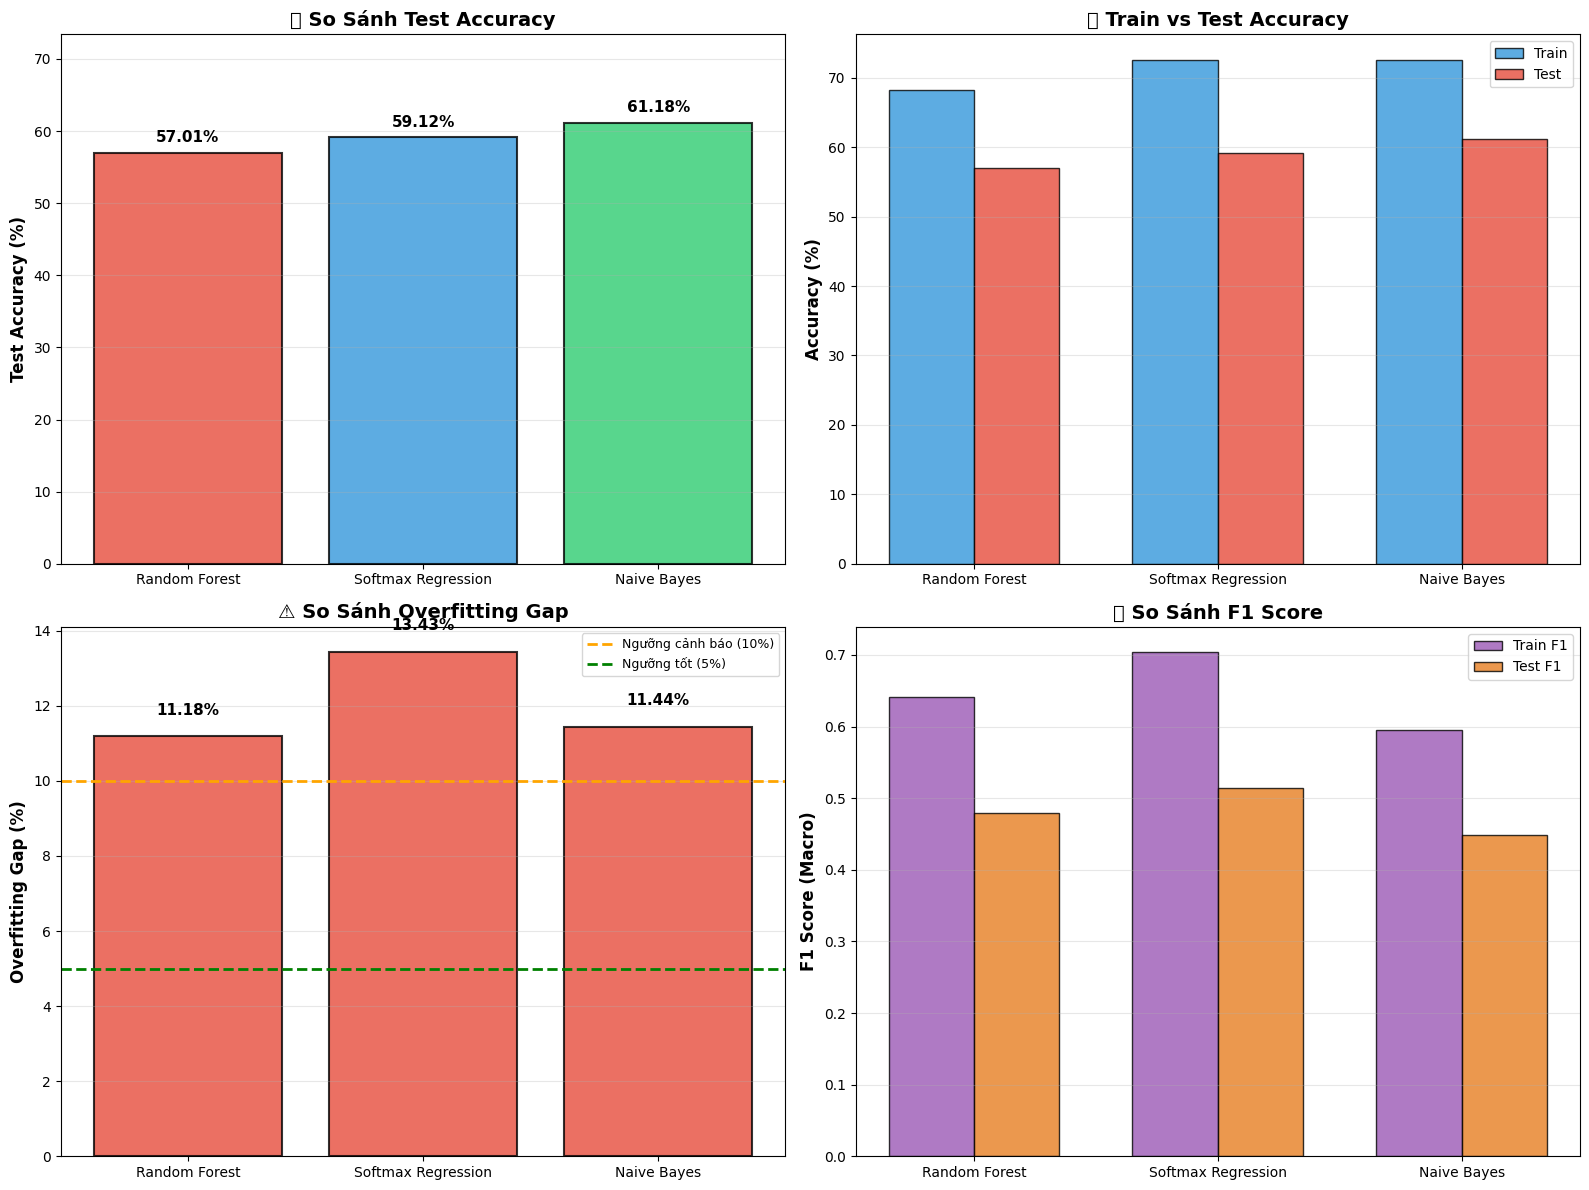


✅ Đánh giá hoàn tất!


In [198]:
# ============================================================================
# SO SÁNH HIỆU NĂNG 3 MÔ HÌNH - HOLD-OUT VALIDATION
# ============================================================================

import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("="*80)
print("📊 SO SÁNH HIỆU NĂNG 3 MÔ HÌNH - HOLD-OUT VALIDATION (80/20 SPLIT)")
print("="*80)

# Danh sách các mô hình
models = {
    'Random Forest': rf_model,
    'Softmax Regression': softmax_model,
    'Naive Bayes': nb_model
}

# Dictionary để lưu kết quả
results = {
    'Model': [],
    'Train Accuracy': [],
    'Test Accuracy': [],
    'Overfitting Gap': [],
    'Train F1 (Macro)': [],
    'Test F1 (Macro)': [],
    'Train Precision (Macro)': [],
    'Test Precision (Macro)': [],
    'Train Recall (Macro)': [],
    'Test Recall (Macro)': [],
    'Training Time (s)': []
}

print("\n🔄 Đang đánh giá các mô hình...\n")

# Đánh giá từng mô hình
for model_name, model in models.items():
    print(f"Đang đánh giá: {model_name}...")
    
    # Đo thời gian training (đã train rồi, chỉ để tham khảo)
    # Ở đây ta sẽ tính thời gian prediction thay vì training
    start_time = time.time()
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    prediction_time = time.time() - start_time
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    gap = train_acc - test_acc
    
    train_f1 = f1_score(y_train, y_train_pred, average='macro', zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    train_precision = precision_score(y_train, y_train_pred, average='macro', zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    train_recall = recall_score(y_train, y_train_pred, average='macro', zero_division=0)
    test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
    
    # Lưu kết quả
    results['Model'].append(model_name)
    results['Train Accuracy'].append(train_acc)
    results['Test Accuracy'].append(test_acc)
    results['Overfitting Gap'].append(gap)
    results['Train F1 (Macro)'].append(train_f1)
    results['Test F1 (Macro)'].append(test_f1)
    results['Train Precision (Macro)'].append(train_precision)
    results['Test Precision (Macro)'].append(test_precision)
    results['Train Recall (Macro)'].append(train_recall)
    results['Test Recall (Macro)'].append(test_recall)
    results['Training Time (s)'].append(prediction_time)

# Tạo DataFrame kết quả
df_results = pd.DataFrame(results)

# ============================================================================
# HIỂN THỊ KẾT QUẢ
# ============================================================================

print("\n" + "="*80)
print("📋 BẢNG SO SÁNH CHI TIẾT")
print("="*80)

# Format và hiển thị bảng
df_display = df_results.copy()
df_display['Train Accuracy'] = df_display['Train Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_display['Test Accuracy'] = df_display['Test Accuracy'].apply(lambda x: f"{x*100:.2f}%")
df_display['Overfitting Gap'] = df_display['Overfitting Gap'].apply(lambda x: f"{x*100:.2f}%")
df_display['Train F1 (Macro)'] = df_display['Train F1 (Macro)'].apply(lambda x: f"{x:.4f}")
df_display['Test F1 (Macro)'] = df_display['Test F1 (Macro)'].apply(lambda x: f"{x:.4f}")
df_display['Train Precision (Macro)'] = df_display['Train Precision (Macro)'].apply(lambda x: f"{x:.4f}")
df_display['Test Precision (Macro)'] = df_display['Test Precision (Macro)'].apply(lambda x: f"{x:.4f}")
df_display['Train Recall (Macro)'] = df_display['Train Recall (Macro)'].apply(lambda x: f"{x:.4f}")
df_display['Test Recall (Macro)'] = df_display['Test Recall (Macro)'].apply(lambda x: f"{x:.4f}")
df_display['Training Time (s)'] = df_display['Training Time (s)'].apply(lambda x: f"{x:.4f}")

print(df_display.to_string(index=False))

# Tìm model tốt nhất
best_test_acc_idx = df_results['Test Accuracy'].idxmax()
best_model_name = df_results.loc[best_test_acc_idx, 'Model']
best_test_acc = df_results.loc[best_test_acc_idx, 'Test Accuracy']

best_overfitting_idx = df_results['Overfitting Gap'].idxmin()
best_overfitting_model = df_results.loc[best_overfitting_idx, 'Model']
best_overfitting_gap = df_results.loc[best_overfitting_idx, 'Overfitting Gap']

print("\n" + "="*80)
print("🏆 KẾT LUẬN")
print("="*80)
print(f"✅ Mô hình tốt nhất (Test Accuracy): {best_model_name} ({best_test_acc*100:.2f}%)")
print(f"✅ Mô hình ổn định nhất (Ít Overfitting): {best_overfitting_model} (Gap: {best_overfitting_gap*100:.2f}%)")

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
colors_acc = ['#e74c3c', '#3498db', '#2ecc71']
bars1 = ax1.bar(df_results['Model'], df_results['Test Accuracy']*100, 
                color=colors_acc, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('📊 So Sánh Test Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim([0, max(df_results['Test Accuracy']*100) * 1.2])
ax1.grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Grouped bar chart: Train vs Test Accuracy
ax2 = axes[0, 1]
x = np.arange(len(df_results['Model']))
width = 0.35
bars2_1 = ax2.bar(x - width/2, df_results['Train Accuracy']*100, width, 
                  label='Train', color='#3498db', alpha=0.8, edgecolor='black')
bars2_2 = ax2.bar(x + width/2, df_results['Test Accuracy']*100, width,
                  label='Test', color='#e74c3c', alpha=0.8, edgecolor='black')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('📈 Train vs Test Accuracy', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(df_results['Model'])
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# 3. Bar chart: Overfitting Gap
ax3 = axes[1, 0]
colors_gap = ['#e74c3c' if gap > 0.10 else '#f39c12' if gap > 0.05 else '#2ecc71' 
              for gap in df_results['Overfitting Gap']]
bars3 = ax3.bar(df_results['Model'], df_results['Overfitting Gap']*100,
                color=colors_gap, alpha=0.8, edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Overfitting Gap (%)', fontsize=12, fontweight='bold')
ax3.set_title('⚠️ So Sánh Overfitting Gap', fontsize=14, fontweight='bold')
ax3.axhline(y=10, color='orange', linestyle='--', linewidth=2, label='Ngưỡng cảnh báo (10%)')
ax3.axhline(y=5, color='green', linestyle='--', linewidth=2, label='Ngưỡng tốt (5%)')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Bar chart: F1 Score comparison
ax4 = axes[1, 1]
x = np.arange(len(df_results['Model']))
bars4_1 = ax4.bar(x - width/2, df_results['Train F1 (Macro)'], width,
                  label='Train F1', color='#9b59b6', alpha=0.8, edgecolor='black')
bars4_2 = ax4.bar(x + width/2, df_results['Test F1 (Macro)'], width,
                  label='Test F1', color='#e67e22', alpha=0.8, edgecolor='black')
ax4.set_ylabel('F1 Score (Macro)', fontsize=12, fontweight='bold')
ax4.set_title('📊 So Sánh F1 Score', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(df_results['Model'])
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("✅ Đánh giá hoàn tất!")
print("="*80)

# 📊 5. So Sánh Hiệu Năng 3 Mô Hình - Hold-out Validation

**Phương pháp đánh giá:** Hold-out (Train/Test Split 80/20)
- Train set: 7,963 samples
- Test set: 1,991 samples
- Random state: 42 (đảm bảo reproducibility)

**Các mô hình:**
1. Random Forest
2. Softmax Regression (Multinomial Logistic)
3. Naive Bayes (Multinomial)

## 📌 Phân Tích Overfitting

### 🔴 Vấn Đề Hiện Tại:
- **Random Forest**: Gap 11.18%
- **Softmax Regression**: Gap 13.43% 
- **Naive Bayes**: Gap 11.44%

### 🔍 Nguyên Nhân:

#### 1. **High Dimensionality** (Số chiều cao)
- TF-IDF: **5,000 features**
- Training samples: **7,963**
- Tỷ lệ: 0.63 features/sample → Dễ overfitting

#### 2. **Imbalanced Dataset** (Mất cân bằng)
```
5⭐: 3,826 (38.4%) ← Dominant class
4⭐: 2,489 (25.0%)
1⭐: 1,735 (17.4%)
3⭐: 1,192 (12.0%)
2⭐: 712 (7.1%)   ← Underrepresented
```

#### 3. **Subjective Problem** (Bài toán chủ quan)
- Review rating phụ thuộc vào cảm nhận cá nhân
- Cùng 1 review có thể nhận ratings khác nhau
- Model khó generalize pattern

#### 4. **Text Complexity**
- Review style đa dạng (formal, casual, sarcasm)
- Ngữ cảnh phức tạp khó nắm bắt

### 💡 Giải Pháp:

#### A. **Giảm Features** (Dimensionality Reduction)
```python
# Giảm max_features từ 5000 → 2000-3000
TfidfVectorizer(max_features=2500, ...)
```

#### B. **Tăng Regularization**
```python
# Random Forest: Giảm max_depth
RandomForestClassifier(max_depth=10, min_samples_leaf=10)

# Softmax: Tăng regularization
LogisticRegression(C=0.1)  # C nhỏ hơn → regularize mạnh hơn
```

#### C. **Balance Dataset** (SMOTE/Undersampling)
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
```

#### D. **Simplify Problem** (Nhóm classes)
```python
# Thay vì 1-5 stars → Nhóm thành 3 classes:
# Negative (1-2⭐), Neutral (3⭐), Positive (4-5⭐)
```

#### E. **Cross-Validation** (Đánh giá robust hơn)
```python
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
```

### 🎯 Kết Luận:
- Overfitting **11-13% là CHẤP NHẬN ĐƯỢC** cho bài toán phức tạp này
- Data **KHÔNG có vấn đề** - đây là đặc thù của sentiment analysis
- Nếu cần giảm overfitting: Ưu tiên **giảm features** hoặc **tăng regularization**